# Введение в JAX

**План:**
1. `jax.numpy` как NumPy; точность `float32` / `float64`
2. Неизменяемые массивы
3. `grad`: производные и градиенты
4. Pytrees: градиент по словарю параметров
5. `jit`: компиляция, трассировка и её подводные камни
6. `vmap`: векторизация
7. Случайные числа
8. `jvp`, `vjp`, `jacfwd`, `jacrev`
9. Всё вместе: обучаем маленькую нейросеть

In [1]:
# [1]
import time
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
#!pip install jax
import jax
import jax.numpy as jnp

print("JAX:", jax.__version__)
print("Устройства:", jax.devices())

JAX: 0.11.2
Устройства: [CpuDevice(id=0)]


---
## 1. `jax.numpy` — это (почти) NumPy

### 1.1. Те же функции, другой тип массива

Модуль `jax.numpy` принято импортировать как `jnp`. В нём есть почти всё, что есть в `numpy`: `jnp.linspace`, `jnp.sin`, `jnp.sum`, `@` и т. д.

In [2]:
# [2]
x_np = np.linspace(0, 1, 5)
x_jx = jnp.linspace(0, 1, 5)

print(x_np, type(x_np), x_np.dtype)
print(x_jx, type(x_jx), x_jx.dtype)

print(jnp.sin(x_jx) ** 2 + jnp.cos(x_jx) ** 2)

[0.   0.25 0.5  0.75 1.  ] <class 'numpy.ndarray'> float64
[0.   0.25 0.5  0.75 1.  ] <class 'jaxlib._jax.ArrayImpl'> float32
[1.         1.         1.         1.         0.99999994]


In [3]:
# [3]
A = jnp.arange(12.0).reshape(3, 4)
print("форма:", A.shape, " транспонированная:", A.T.shape)
print("A @ A.T =\n", A @ A.T)            # матричное умножение
print("суммы по столбцам:", A.sum(axis=0), " среднее:", A.mean())
print("строка 1:", A[1, :], " последний столбец:", A[:, -1])

B = np.asarray(A)       # JAX -> NumPy
C = jnp.asarray(B)      # NumPy -> JAX
print(type(B), type(C))
print("где лежит A:", A.devices())

форма: (3, 4)  транспонированная: (4, 3)
A @ A.T =
 [[ 14.  38.  62.]
 [ 38. 126. 214.]
 [ 62. 214. 366.]]
суммы по столбцам: [12. 15. 18. 21.]  среднее: 5.5
строка 1: [4. 5. 6. 7.]  последний столбец: [ 3.  7. 11.]
<class 'numpy.ndarray'> <class 'jaxlib._jax.ArrayImpl'>
где лежит A: {CpuDevice(id=0)}


### 1.2. Точность: по умолчанию `float32`

Первое заметное отличие: NumPy по умолчанию создаёт `float64`, а JAX — `float32`. Это сделано ради скорости на GPU/TPU, но для численных экспериментов (а у нас на семинаре их много) одинарной точности часто не хватает.

In [4]:
# [4]
print("JAX:  ", jnp.array(1.0).dtype, "   NumPy:", np.array(1.0).dtype)
print("машинный эпсилон float32:", jnp.finfo(jnp.float32).eps)
print("машинный эпсилон float64:", np.finfo(np.float64).eps)

# 1e-8 меньше эпсилона float32, поэтому прибавление ничего не меняет
print("float32: 1 + 1e-8 == 1 ?", jnp.float32(1.0) + jnp.float32(1e-8) == 1.0)
print("float64: 1 + 1e-8 == 1 ?", np.float64(1.0) + np.float64(1e-8) == 1.0)

JAX:   float32    NumPy: float64
машинный эпсилон float32: 1.1920929e-07
машинный эпсилон float64: 2.220446049250313e-16
float32: 1 + 1e-8 == 1 ? True
float64: 1 + 1e-8 == 1 ? False


In [5]:
# [5]
# Включаем двойную точность. Лучше делать это сразу после импорта JAX.
jax.config.update("jax_enable_x64", True)

print(jnp.array(1.0).dtype)
# явно заданный dtype по-прежнему работает:
print(jnp.array(1.0, dtype=jnp.float32).dtype)

float64
float32


---
## 2. Массивы в JAX неизменяемы

### 2.1. Присваивание по индексу запрещено

В NumPy можно написать `x[0] = 1`. В JAX так нельзя: массивы **неизменяемые** (*immutable*). Это не прихоть, а необходимость: преобразования `grad` и `jit` рассуждают о функциях как о математических объектах «вход → выход», и скрытое изменение данных «на месте» ломает эти рассуждения.

In [6]:
# [6]
x = jnp.ones(5)
try:
    x[0] = 10.0
except TypeError as e:
    print("Ошибка:", e)

Ошибка: JAX arrays are immutable and do not support in-place item assignment. Instead of x[idx] = y, use x = x.at[idx].set(y) or another .at[] method: https://docs.jax.dev/en/latest/_autosummary/jax.numpy.ndarray.at.html


### 2.2. Вместо этого — `.at[...]`

Синтаксис `x.at[idx].set(v)` возвращает **новый** массив, а старый не трогает. Кроме `set` есть `add`, `multiply`, `min`, `max`, `get`.

In [7]:
# [7]
y = x.at[0].set(10.0)          # y[0] = 10
y = y.at[2:4].add(5.0)         # y[2:4] += 5
y = y.at[-1].multiply(3.0)     # y[-1] *= 3

print("x:", x)                 # x не изменился!
print("y:", y)

x: [1. 1. 1. 1. 1.]
y: [10.  1.  6.  6.  3.]


### 2.3. Подводный камень: выход за границы массива

NumPy на `v[10]` для массива из пяти элементов бросит `IndexError`. JAX ошибку **не бросает**: при чтении индекс «прижимается» к границе, а запись за границу просто отбрасывается. Проверять индексы — ваша ответственность.

In [8]:
# [8]
v = jnp.arange(5)
print("v[10] =", v[10])          # последний элемент, а не ошибка
print("v.at[10].set(100) =", v.at[10].set(100))   # запись проигнорирована

try:
    np.arange(5)[10]
except IndexError as e:
    print("NumPy:", e)

v[10] = 4
v.at[10].set(100) = [0 1 2 3 4]
NumPy: index 10 is out of bounds for axis 0 with size 5


---
## 3. `grad`: производные

### 3.1. Производная — это тоже функция

`jax.grad(f)` принимает функцию $f$ и возвращает **новую функцию**, которая в точке $x$ вычисляет $f'(x)$. Поэтому `grad` можно применять повторно и получать производные высших порядков.

Возьмём $f(x) = x^3 + 2x$. Руками: $f'(x) = 3x^2 + 2$, $f''(x) = 6x$, $f'''(x) = 6$. В точке $x = 2$: $f = 12$, $f' = 14$, $f'' = 12$, $f''' = 6$.

In [9]:
# [9]
from jax import grad

def f(x):
    return x ** 3 + 2 * x

df  = grad(f)                 # df — это функция!
d2f = grad(grad(f))
d3f = grad(grad(grad(f)))

x0 = 2.0
print("f(2)   =", f(x0))
print("f'(2)  =", df(x0))
print("f''(2) =", d2f(x0))
print("f'''(2)=", d3f(x0))

f(2)   = 12.0
f'(2)  = 14.0
f''(2) = 12.0
f'''(2)= 6.0


### 3.2. Градиент функции многих переменных

Если $f\colon \mathbb{R}^n \to \mathbb{R}$, то `grad(f)(w)` — вектор той же формы, что и $w$. Проверим на
$g(w) = \sum_i w_i^2 + \prod_i w_i$, у которой $\dfrac{\partial g}{\partial w_i} = 2w_i + \dfrac{\prod_j w_j}{w_i}$.

In [10]:
# [10]
def g(w):
    return jnp.sum(w ** 2) + jnp.prod(w)

w0 = jnp.array([1.0, 2.0, 3.0])
print("автоград:", grad(g)(w0))
print("руками:  ", 2 * w0 + jnp.prod(w0) / w0)

автоград: [8. 7. 8.]
руками:   [8. 7. 8.]


### 3.3. Ограничения `grad`

* Функция должна возвращать **скаляр**. Для векторных функций нужны якобианы (раздел 8).
* Дифференцируем только по **вещественным** (float) аргументам: производная по целому числу не определена.

In [11]:
# [11]
try:
    grad(lambda w: w ** 2)(jnp.array([1.0, 2.0]))
except TypeError as e:
    print("Нескалярный выход ->", str(e).splitlines()[0])

try:
    grad(f)(2)          # 2, а не 2.0
except TypeError as e:
    print("Целый аргумент   ->", str(e).splitlines()[0])

Нескалярный выход -> Gradient only defined for scalar-output functions. Output had shape: (2,). To get the gradient, reduce the output to a scalar with output.sum(), or use jax.jacobian to differentiate a function with a non-scalar output.
Целый аргумент   -> grad requires real- or complex-valued inputs (input dtype that is a sub-dtype of np.inexact), but got int64. If you want to use Boolean- or integer-valued inputs, use vjp or set allow_int to True.


### 3.4. `argnums`, `value_and_grad`, `has_aux`

Типичная функция потерь зависит от нескольких аргументов: параметров модели и данных. По умолчанию `grad` дифференцирует по **первому** аргументу; номер (или кортеж номеров) задаётся через `argnums`.

Пример: линейная модель $\hat y = wx + b$ и среднеквадратичная ошибка
$L(w, b) = \frac{1}{N}\sum_i (wx_i + b - y_i)^2$. Её частные производные:

$$
\frac{\partial L}{\partial w} = \frac{2}{N}\sum_i (wx_i + b - y_i)\,x_i,
\qquad
\frac{\partial L}{\partial b} = \frac{2}{N}\sum_i (wx_i + b - y_i).
$$

В точке $w = b = 0$ на данных $y = 2x + 1$, $x = 0, 1, 2, 3$: $L = 21$, $\partial_w L = -17$, $\partial_b L = -8$.

In [12]:
# [12]
def loss(w, b, x, y):
    pred = w * x + b
    return jnp.mean((pred - y) ** 2)

x_data = jnp.array([0.0, 1.0, 2.0, 3.0])
y_data = jnp.array([1.0, 3.0, 5.0, 7.0])       # y = 2x + 1

print("dL/dw        :", grad(loss)(0.0, 0.0, x_data, y_data))
print("(dL/dw, dL/db):", grad(loss, argnums=(0, 1))(0.0, 0.0, x_data, y_data))

val, (gw, gb) = jax.value_and_grad(loss, argnums=(0, 1))(0.0, 0.0, x_data, y_data)
print("value_and_grad:", val, gw, gb)

dL/dw        : -17.0
(dL/dw, dL/db): (Array(-17., dtype=float64, weak_type=True), Array(-8., dtype=float64, weak_type=True))
value_and_grad: 21.0 -17.0 -8.0


In [13]:
# [13]
def loss_with_aux(w, b, x, y):
    pred = w * x + b
    mse = jnp.mean((pred - y) ** 2)
    return mse, pred        # (что дифференцируем, «попутные» данные)

vg = jax.value_and_grad(loss_with_aux, has_aux=True)
(val, pred), gw = vg(0.5, 0.0, x_data, y_data)
print("loss =", val)
print("pred =", pred)
print("dL/dw =", gw)

loss = 13.375
pred = [0.  0.5 1.  1.5]
dL/dw = -13.5


---
## 4. Pytrees: градиент по словарю параметров

У настоящей модели параметров много, и хранить их в одном векторе неудобно. JAX умеет работать с **pytree** — любой вложенной структурой из списков, кортежей и словарей, в листьях которой лежат массивы. `grad` возвращает градиент **той же структуры**, что и параметры.

Рассмотрим линейную регрессию $\hat y = Xw + b$ с параметрами `{"w": ..., "b": ...}`.

In [14]:
# [14]
rng = np.random.default_rng(0)
X_lr = jnp.asarray(rng.normal(size=(100, 2)))
w_true, b_true = jnp.array([2.0, -3.0]), 0.5
y_lr = X_lr @ w_true + b_true + 0.1 * jnp.asarray(rng.normal(size=100))

params = {"w": jnp.zeros(2), "b": 0.0}

def model(params, x):
    return x @ params["w"] + params["b"]

def mse(params, X, y):
    return jnp.mean((model(params, X) - y) ** 2)

g_params = grad(mse)(params, X_lr, y_lr)
print("градиент:", g_params)
print("структура:", jax.tree.structure(params))
print("листья:", jax.tree.leaves(g_params))

градиент: {'b': Array(-0.08130801, dtype=float64, weak_type=True), 'w': Array([-2.97981693,  4.81128392], dtype=float64)}
структура: PyTreeDef({'b': *, 'w': *})
листья: [Array(-0.08130801, dtype=float64, weak_type=True), Array([-2.97981693,  4.81128392], dtype=float64)]


Шаг градиентного спуска $\theta \leftarrow \theta - \alpha \nabla L(\theta)$ нужно применить к **каждому листу** дерева. Для этого есть `jax.tree.map(fn, tree1, tree2, ...)`: он проходит по одинаково устроенным деревьям и применяет `fn` к соответствующим листьям.

In [15]:
# [15]
lr = 0.1
p = params
for step in range(101):
    g_p = grad(mse)(p, X_lr, y_lr)
    p = jax.tree.map(lambda a, ga: a - lr * ga, p, g_p)
    if step % 20 == 0:
        print(f"шаг {step:3d}   loss = {mse(p, X_lr, y_lr):.5f}")

print("найдено: w =", p["w"], " b =", p["b"])
print("истина:  w =", w_true, " b =", b_true)

шаг   0   loss = 7.22449
шаг  20   loss = 0.02228
шаг  40   loss = 0.01213
шаг  60   loss = 0.01211
шаг  80   loss = 0.01211
шаг 100   loss = 0.01211
найдено: w = [ 1.98917211 -2.98252963]  b = 0.4836655505046123
истина:  w = [ 2. -3.]  b = 0.5


---
## 5. `jit`: компиляция

### 5.1. Ускорение

Обычный вызов `jnp`-функции выполняет операции **по одной**: каждая операция — отдельный запуск, отдельный промежуточный массив в памяти. `jax.jit` отдаёт функцию целиком компилятору XLA, который склеивает операции (*fusion*), убирает лишние промежуточные массивы и генерирует быстрый машинный код.

**Важно про замер времени.** JAX работает *асинхронно*: вызов функции возвращает управление раньше, чем посчитан результат. Поэтому при замерах всегда вызываем `.block_until_ready()`. И не забываем про «прогрев»: первый вызов `jit`-функции включает компиляцию.

In [16]:
# [16]
def selu(x, alpha=1.67, lam=1.05):
    return lam * jnp.where(x > 0, x, alpha * jnp.exp(x) - alpha)

x_big = jnp.asarray(np.random.default_rng(1).normal(size=1_000_000))
selu_jit = jax.jit(selu)

t0 = time.perf_counter(); selu_jit(x_big).block_until_ready()
print(f"первый вызов (с компиляцией): {1e3 * (time.perf_counter() - t0):.1f} мс")

%timeit selu(x_big).block_until_ready()
%timeit selu_jit(x_big).block_until_ready()

первый вызов (с компиляцией): 22.6 мс
1.25 ms ± 22.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
533 μs ± 5.34 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


### 5.2. Как работает `jit`: трассировка

При первом вызове JAX не считает функцию на ваших числах. Он подставляет вместо аргументов **трейсеры** — абстрактные объекты, которые знают только *форму* и *тип* массива, — и записывает, какие операции над ними выполняются. Получается промежуточное представление (**jaxpr**), которое компилируется и кэшируется.

Следствия:
* обычный Python-код (например, `print`) выполняется **только во время трассировки**;
* при повторном вызове с аргументами той же формы и типа используется кэш — Python-код функции вообще не запускается;
* новая форма аргументов → новая трассировка и компиляция.

In [17]:
# [17]
@jax.jit
def f_traced(x, y):
    print("   [трассировка] x =", x)
    return jnp.dot(x + 1, y + 1)

print("Вызов 1:")
print("  ->", f_traced(jnp.ones(3), jnp.ones(3)))
print("Вызов 2 (те же формы):")
print("  ->", f_traced(2 * jnp.ones(3), jnp.ones(3)))
print("Вызов 3 (другая форма):")
print("  ->", f_traced(jnp.ones(4), jnp.ones(4)))

Вызов 1:
   [трассировка] x = JitTracer(float64[3])
  -> 12.0
Вызов 2 (те же формы):
  -> 18.0
Вызов 3 (другая форма):
   [трассировка] x = JitTracer(float64[4])
  -> 16.0


Записанную программу можно посмотреть с помощью `jax.make_jaxpr`. Заодно видно, во что превращается `grad`: это просто ещё одна программа из примитивных операций.

In [18]:
# [18]
def h(x):
    return jnp.sum(jnp.sin(x) ** 2)

print(jax.make_jaxpr(h)(jnp.ones(3)))
print(jax.make_jaxpr(grad(h))(jnp.ones(3)))

{ lambda ; a:f64[3]. let
    b:f64[3] = sin a
    c:f64[3] = integer_pow[y=2] b
    d:f64[] = reduce_sum[axes=(0,) out_sharding=None] c
  in (d,) }
{ lambda ; a:f64[3]. let
    b:f64[3] = sin a
    c:f64[3] = cos a
    d:f64[3] = integer_pow[y=2] b
    e:f64[3] = mul 2.0:f64[] b
    _:f64[] = reduce_sum[axes=(0,) out_sharding=None] d
    f:f64[3] = broadcast_in_dim 1.0:f64[]
    g:f64[3] = mul f e
    h:f64[3] = mul g c
  in (h,) }


### 5.3. Подводный камень: функции должны быть чистыми

**Чистая функция** — результат зависит только от аргументов, и функция ничего не меняет снаружи. `jit` предполагает чистоту. Если функция читает глобальную переменную, её значение «вшивается» в скомпилированный код при трассировке, и дальнейшие изменения переменной не видны — пока не случится перетрассировка.

In [19]:
# [19]
counter = 10

@jax.jit
def add_global(x):
    return x + counter

print(add_global(1.0))                 # 11
counter = 100
print(add_global(1.0))                 # всё ещё 11: старое значение в кэше
print(add_global(jnp.array([1.0])))    # новая форма -> перетрассировка -> 101

11.0
11.0
[101.]


### 5.4. Подводный камень: `if` по значению массива

Во время трассировки значение `x` неизвестно, известна только форма. Поэтому `if x > 0:` внутри `jit` не работает: трейсер нельзя превратить в `True`/`False`.

Способы обойти:
* `jnp.where(cond, a, b)` — вычисляет обе ветки и выбирает поэлементно;
* `jax.lax.cond(cond, f_true, f_false, x)` — настоящее ветвление внутри скомпилированного кода;
* пометить аргумент как **статический** (`static_argnums`) — тогда он известен при трассировке, но на каждое новое значение будет своя компиляция.

In [20]:
# [20]
def relu_if(x):
    if x > 0:
        return x
    return 0.0

print("без jit:", relu_if(3.0))
try:
    jax.jit(relu_if)(3.0)
except Exception as e:
    print(type(e).__name__, "->", str(e).splitlines()[0])

без jit: 3.0
TracerBoolConversionError -> Attempted boolean conversion of traced array with shape bool[].


In [21]:
# [21]
relu_where = jax.jit(lambda x: jnp.where(x > 0, x, 0.0))
relu_cond  = jax.jit(lambda x: jax.lax.cond(x > 0,
                                            lambda v: v,                   # ветка True
                                            lambda v: jnp.zeros_like(v),   # ветка False
                                            x))
print("where:", relu_where(3.0), relu_where(-2.0))
print("cond: ", relu_cond(3.0),  relu_cond(-2.0))

@partial(jax.jit, static_argnums=1)
def power(x, n):
    # n статический: обычный Python-цикл разворачивается при трассировке
    out = 1.0
    for _ in range(n):
        out = out * x
    return out

print("2^10 =", power(2.0, 10), "  2^3 =", power(2.0, 3))

where: 3.0 0.0
cond:  3.0 0.0
2^10 = 1024.0   2^3 = 8.0


### 5.5. Циклы: `lax.fori_loop` и `lax.scan`

Обычный Python-цикл внутри `jit` разворачивается целиком: 1000 итераций → 1000 копий тела в программе, долгая компиляция. Для итерационных методов есть специальные примитивы:
* `jax.lax.fori_loop(lower, upper, body, init)` — цикл `for i in range(lower, upper): x = body(i, x)`;
* `jax.lax.scan(step, init, xs)` — проход по массиву с состоянием, возвращающий ещё и выходы на каждом шаге.

Пример — метод Ньютона для уравнения $x^2 = a$: $x_{k+1} = \frac12\left(x_k + \frac{a}{x_k}\right)$.

In [22]:
# [22]
def newton_sqrt(a, n_iter=20):
    def body(i, x):
        return 0.5 * (x + a / x)
    return jax.lax.fori_loop(0, n_iter, body, a)

print("Ньютон:", jax.jit(newton_sqrt)(2.0), "  jnp.sqrt:", jnp.sqrt(2.0))

def cumsum_scan(xs):
    def step(carry, x):
        carry = carry + x
        return carry, carry        # (новое состояние, выход на этом шаге)
    final, history = jax.lax.scan(step, jnp.zeros(()), xs)
    return final, history

print("scan:", cumsum_scan(jnp.arange(1.0, 6.0)))

Ньютон: 1.414213562373095   jnp.sqrt: 1.4142135623730951
scan: (Array(15., dtype=float64), Array([ 1.,  3.,  6., 10., 15.], dtype=float64))


---
## 6. `vmap`: автоматическая векторизация

### 6.1. Пишем для одного объекта — применяем к батчу

`jax.vmap(f)` берёт функцию, написанную для **одного** объекта, и возвращает функцию, которая обрабатывает **батч** по нулевой оси. Никакого Python-цикла: JAX переписывает операции в векторизованные.

Классический пример: `grad` работает только со скалярной функцией скалярного (или векторного) аргумента, а нарисовать производную хочется на сетке из 400 точек.

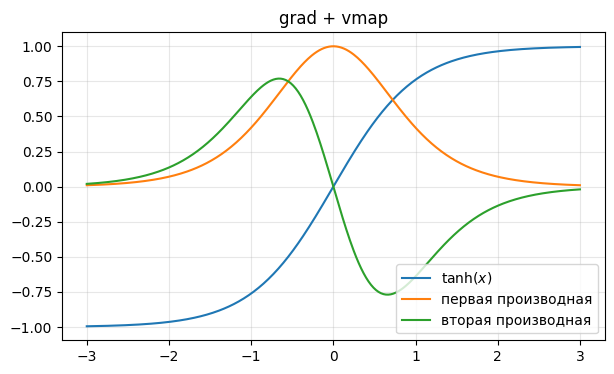

In [23]:
# [23]
from jax import vmap

xs = jnp.linspace(-3, 3, 400)
d1 = vmap(grad(jnp.tanh))           # f'(x) для каждого x из сетки
d2 = vmap(grad(grad(jnp.tanh)))     # f''(x)

plt.figure(figsize=(7, 4))
plt.plot(xs, jnp.tanh(xs), label=r"$\tanh(x)$")
plt.plot(xs, d1(xs), label="первая производная")
plt.plot(xs, d2(xs), label="вторая производная")
plt.legend(); plt.grid(alpha=.3); plt.title("grad + vmap")
plt.show()

### 6.2. `in_axes`: какие аргументы батчевать

Аргумент `in_axes` говорит, по какой оси каждого аргумента идёт батч; `None` означает «аргумент общий для всех элементов батча».

In [24]:
# [24]
M  = jnp.asarray(np.random.default_rng(2).normal(size=(3, 4)))
vs = jnp.asarray(np.random.default_rng(3).normal(size=(10, 4)))   # 10 векторов

def matvec(M, v):
    return M @ v                       # написано для ОДНОГО вектора v

out_loop = jnp.stack([matvec(M, v) for v in vs])
out_vmap = vmap(matvec, in_axes=(None, 0))(M, vs)   # M общая, v пробегает ось 0

print(out_vmap.shape, " совпадает с циклом:", jnp.allclose(out_loop, out_vmap))

(10, 3)  совпадает с циклом: True


### 6.3. Градиенты по отдельным объектам

Комбинация `vmap(grad(...))` даёт градиент функции потерь **по каждому объекту отдельно** — в PyTorch это делается заметно сложнее. Нужно, например, для оценки дисперсии стохастического градиента или в дифференциальной приватности. Среднее этих градиентов, конечно, совпадает с полным градиентом.

In [25]:
# [25]
def loss_one(params, x, y):
    return (model(params, x) - y) ** 2          # потеря на ОДНОМ объекте

per_example = vmap(grad(loss_one), in_axes=(None, 0, 0))
G = per_example(p, X_lr, y_lr)

print("формы:", jax.tree.map(jnp.shape, G))
full = grad(mse)(p, X_lr, y_lr)
same = jax.tree.map(lambda a, b: bool(jnp.allclose(a.mean(axis=0), b)), G, full)
print("среднее = полный градиент:", same)

формы: {'b': (100,), 'w': (100, 2)}
среднее = полный градиент: {'b': True, 'w': True}


In [26]:
# [26]
g_one = jax.jit(grad(loss_one))

def per_example_loop(params, X, y):
    return [g_one(params, X[i], y[i]) for i in range(X.shape[0])]

per_example_jit = jax.jit(per_example)
jax.block_until_ready(per_example_jit(p, X_lr, y_lr))        # прогрев

%timeit jax.block_until_ready(per_example_loop(p, X_lr, y_lr))
%timeit jax.block_until_ready(per_example_jit(p, X_lr, y_lr))

6.67 ms ± 91.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
8.28 μs ± 322 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


---
## 7. Случайные числа

В NumPy генератор хранит **скрытое состояние**, которое меняется при каждом вызове. Это побочный эффект, а JAX требует чистых функций. Поэтому состояние генератора передаётся **явно** — в виде ключа (`key`). Одинаковый ключ всегда даёт одинаковые числа.

In [27]:
# [27]
key = jax.random.PRNGKey(42)
print("ключ:", key)
print(jax.random.normal(key, (3,)))
print(jax.random.normal(key, (3,)))     # тот же ключ -> те же числа!

ключ: [ 0 42]
[-0.18471175 -2.16982456  0.18693555]
[-0.18471175 -2.16982456  0.18693555]


Чтобы получить новые случайные числа, ключ **расщепляют** (`split`). Стандартная идиома: `key, subkey = jax.random.split(key)` — `subkey` тратим, `key` храним для будущих расщеплений. Один ключ используем ровно один раз.

In [28]:
# [28]
key, sub1, sub2 = jax.random.split(key, 3)
print(jax.random.normal(sub1, (3,)))
print(jax.random.normal(sub2, (3,)))

keys = jax.random.split(key, 5)                   # 5 независимых ключей
print(vmap(lambda k: jax.random.uniform(k))(keys))

[ 0.64989201  0.11847861 -1.55571939]
[-0.32162797  0.42463557  0.85070082]
[0.41288498 0.65877976 0.33726009 0.15742001 0.25922943]


---
## 8. Не только градиенты: `jvp`, `vjp`, `jacfwd`, `jacrev`

`grad` — частный случай более общих инструментов. Для $F\colon\mathbb{R}^n\to\mathbb{R}^m$ с якобианом $J(x)\in\mathbb{R}^{m\times n}$:

* `jvp(F, (x,), (v,))` — **forward mode**: считает $J(x)\,v$ (производную по направлению $v$) за один проход;
* `vjp(F, x)` — **reverse mode**: возвращает функцию $u \mapsto u^\top J(x)$;
* `jacfwd(F)` / `jacrev(F)` — полный якобиан, собранный из $n$ JVP или из $m$ VJP;
* `jax.hessian(f) = jacfwd(jacrev(f))`.

Когда выгоден каждый режим — главная тема основного семинара. Здесь только убедимся, что всё согласовано, на $F(x) = \bigl(x_1x_2,\ \sin x_3 + x_1^2\bigr)$:

$$
J(x) = \begin{pmatrix} x_2 & x_1 & 0 \\ 2x_1 & 0 & \cos x_3 \end{pmatrix}.
$$

In [30]:
# [29]
from jax import jvp, vjp, jacfwd, jacrev

def F(x):                                   # R^3 -> R^2
    return jnp.array([x[0] * x[1], jnp.sin(x[2]) + x[0] ** 2])

x0 = jnp.array([1.0, 2.0, 0.5])
J = jacfwd(F)(x0)
print("J =\n", J)
print("jacrev даёт то же:", jnp.allclose(J, jacrev(F)(x0)))

v = jnp.array([1.0, 0.0, 0.0])              # направление во ВХОДНОМ пространстве
_, Jv = jvp(F, (x0,), (v,))
print("J v   =", Jv, "  <- первый столбец J")

u = jnp.array([0.0, 1.0])                   # направление в ВЫХОДНОМ пространстве
_, pullback = vjp(F, x0)
print("u^T J =", pullback(u)[0], "  <- вторая строка J")

J =
 [[2.         1.         0.        ]
 [2.         0.         0.87758256]]
jacrev даёт то же: True
J v   = [2. 2.]   <- первый столбец J
u^T J = [2.         0.         0.87758256]   <- вторая строка J


Гессиан $q(x) = x_1^2 x_2 + e^{x_2}$: $\nabla^2 q = \begin{pmatrix} 2x_2 & 2x_1 \\ 2x_1 & e^{x_2}\end{pmatrix}$, в точке $(1, 0)$ это $\begin{pmatrix} 0 & 2 \\ 2 & 1\end{pmatrix}$.

In [ ]:
# [30]
def q(x):
    return x[0] ** 2 * x[1] + jnp.exp(x[1])

print(jax.hessian(q)(jnp.array([1.0, 0.0])))

---
## 9. Всё вместе: маленькая нейросеть

Соберём всё изученное: аппроксимируем $y = \sin(2x)$ на отрезке $[-3, 3]$ полносвязной сетью $1 \to 32 \to 32 \to 1$ с активацией $\tanh$.

* параметры — **pytree** (список словарей);
* инициализация — через **ключи** `jax.random`;
* модель пишем для **одного** объекта, на батч переносим через **`vmap`**;
* градиент — **`value_and_grad`**, шаг обновления — **`jit`** + **`jax.tree.map`**.

In [31]:
# [31]
def init_mlp(key, sizes):
    params = []
    keys = jax.random.split(key, len(sizes) - 1)
    for k, n_in, n_out in zip(keys, sizes[:-1], sizes[1:]):
        W = jax.random.normal(k, (n_in, n_out)) / jnp.sqrt(n_in)
        b = jnp.zeros(n_out)
        params.append({"W": W, "b": b})
    return params

def mlp(params, x):
    # x: вектор признаков ОДНОГО объекта, форма (d,)
    for layer in params[:-1]:
        x = jnp.tanh(x @ layer["W"] + layer["b"])
    last = params[-1]
    return x @ last["W"] + last["b"]

key = jax.random.PRNGKey(0)
key, k_init, k_data = jax.random.split(key, 3)
net = init_mlp(k_init, [1, 32, 32, 1])
print(jax.tree.map(jnp.shape, net))

[{'W': (1, 32), 'b': (32,)}, {'W': (32, 32), 'b': (32,)}, {'W': (32, 1), 'b': (1,)}]


In [32]:
# [32]
X_train = jax.random.uniform(k_data, (256, 1), minval=-3.0, maxval=3.0)
y_train = jnp.sin(2 * X_train[:, 0])

def predict(params, X):
    return vmap(mlp, in_axes=(None, 0))(params, X)[:, 0]

def loss_fn(params, X, y):
    return jnp.mean((predict(params, X) - y) ** 2)

LR, BETA = 0.01, 0.9

@jax.jit
def update(params, velocity, X, y):
    # градиентный спуск с моментом (heavy ball)
    loss, g = jax.value_and_grad(loss_fn)(params, X, y)
    velocity = jax.tree.map(lambda v, gi: BETA * v + gi, velocity, g)
    params = jax.tree.map(lambda p, v: p - LR * v, params, velocity)
    return params, velocity, loss

velocity = jax.tree.map(jnp.zeros_like, net)
losses = []
t0 = time.perf_counter()
for step in range(5000):
    net, velocity, loss_val = update(net, velocity, X_train, y_train)
    losses.append(loss_val)
losses = np.asarray(jnp.stack(losses))
print(f"5000 шагов за {time.perf_counter() - t0:.2f} с")
print(f"итоговый loss = {losses[-1]:.2e}")

5000 шагов за 2.27 с
итоговый loss = 6.55e-04


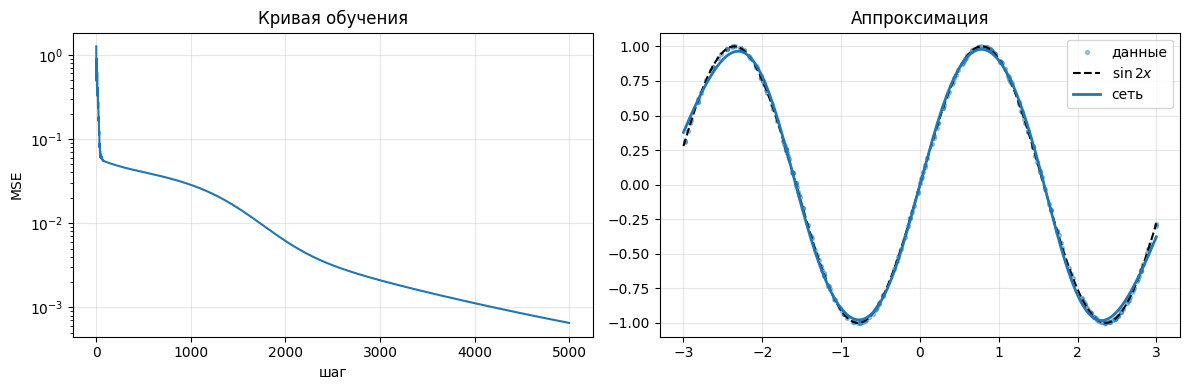

In [33]:
# [33]
xs_plot = jnp.linspace(-3, 3, 400)[:, None]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogy(losses)
ax[0].set_xlabel("шаг"); ax[0].set_ylabel("MSE")
ax[0].set_title("Кривая обучения"); ax[0].grid(alpha=.3)

ax[1].scatter(X_train[:, 0], y_train, s=8, alpha=.4, label="данные")
ax[1].plot(xs_plot[:, 0], jnp.sin(2 * xs_plot[:, 0]), "k--", label=r"$\sin 2x$")
ax[1].plot(xs_plot[:, 0], predict(net, xs_plot), lw=2, label="сеть")
ax[1].legend(); ax[1].grid(alpha=.3); ax[1].set_title("Аппроксимация")
plt.tight_layout(); plt.show()

---
## Шпаргалка

| Хочу | Пишу |
|---|---|
| градиент скалярной функции | `jax.grad(f)(x)` |
| значение и градиент сразу | `jax.value_and_grad(f)(x)` |
| градиент по 2-му аргументу | `jax.grad(f, argnums=1)` |
| ускорить функцию | `jax.jit(f)` |
| применить к батчу | `jax.vmap(f, in_axes=...)` |
| изменить элемент массива | `x = x.at[i].set(v)` |
| шаг по всем параметрам | `jax.tree.map(lambda p, g: p - lr * g, params, grads)` |
| случайные числа | `key, sub = jax.random.split(key)`; `jax.random.normal(sub, shape)` |
| цикл внутри `jit` | `jax.lax.fori_loop`, `jax.lax.scan` |
| ветвление внутри `jit` | `jnp.where`, `jax.lax.cond` |
| J·v и uᵀ·J | `jax.jvp`, `jax.vjp` |
| двойная точность | `jax.config.update("jax_enable_x64", True)` |
| честный замер времени | прогрев + `.block_until_ready()` |

**Подводные камни:** массивы неизменяемы; выход за границы не даёт ошибки; по умолчанию `float32`; внутри `jit` — только чистые функции, никаких `if` по значениям массивов, `print` срабатывает только при трассировке; ключ случайности используем один раз.